#📌 Extracción

In [17]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Obtenemos los datos de la URL
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
respuesta = requests.get(url)
datos_json = respuesta.json()

# 2. "Aplanamos" los datos anidados (Esta es la solución a tu error)
df = pd.json_normalize(datos_json)

# Mostrar la cantidad de filas, columnas y las primeras 5 filas
print(f"Dataset cargado y aplanado: {df.shape[0]} filas y {df.shape[1]} columnas.")
display(df.head())

Dataset cargado y aplanado: 7267 filas y 21 columnas.


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformación

In [18]:
# 1. Eliminar filas duplicadas si las hay
df = df.drop_duplicates()

# 2. Buscar automáticamente el nombre exacto de las columnas clave
col_mensual = [col for col in df.columns if 'Monthly' in col or 'monthly' in col][0]
col_total = [col for col in df.columns if 'Total' in col or 'total' in col][0]
col_churn = [col for col in df.columns if 'Churn' in col or 'churn' in col][0]

print(f"Columnas detectadas -> Mensual: {col_mensual} | Total: {col_total} | Evasión: {col_churn}")

# 3. Corregir el gasto total (Forzamos conversión a números y rellenamos nulos con 0)
df[col_total] = pd.to_numeric(df[col_total], errors='coerce')
df[col_total] = df[col_total].fillna(0)

# 4. Estandarizar la columna de Evasión (Churn)
# Quitamos espacios vacíos y aseguramos que todo empiece con mayúscula (Yes, No)
df[col_churn] = df[col_churn].astype(str).str.strip().str.title()
# Mapeamos a 1 y 0
df['Churn_Binario'] = df[col_churn].map({'Yes': 1, 'No': 0, 'Si': 1, 'Sí': 1})
# Si un cliente no tenía dato (los 224 nulos), asumimos que no ha evadido (0)
df['Churn_Binario'] = df['Churn_Binario'].fillna(0)

# 5. Crear la columna Cuentas_Diarias
df['Cuentas_Diarias'] = df[col_mensual] / 30

# 6. Verificamos que todo salió perfecto
print(f"Transformación completada. Valores nulos en Churn_Binario: {df['Churn_Binario'].isnull().sum()}")
display(df[[col_mensual, 'Cuentas_Diarias', 'Churn_Binario']].head())

Columnas detectadas -> Mensual: account.Charges.Monthly | Total: account.Charges.Total | Evasión: Churn
Transformación completada. Valores nulos en Churn_Binario: 0


,account.Charges.Monthly,Cuentas_Diarias,Churn_Binario
0,65.6,2.186667,0.0
1,59.9,1.996667,0.0
2,73.9,2.463333,1.0
3,98.0,3.266667,1.0
4,83.9,2.796667,1.0


#📊 Carga y análisis

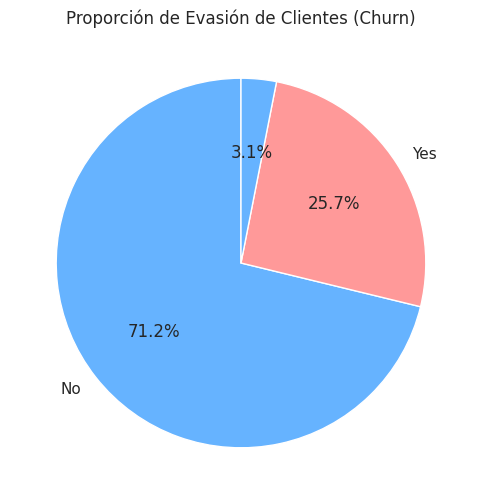

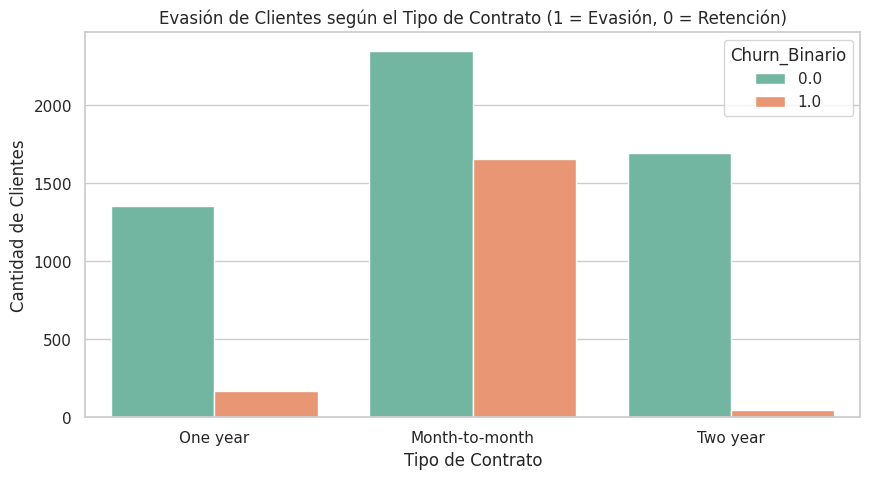

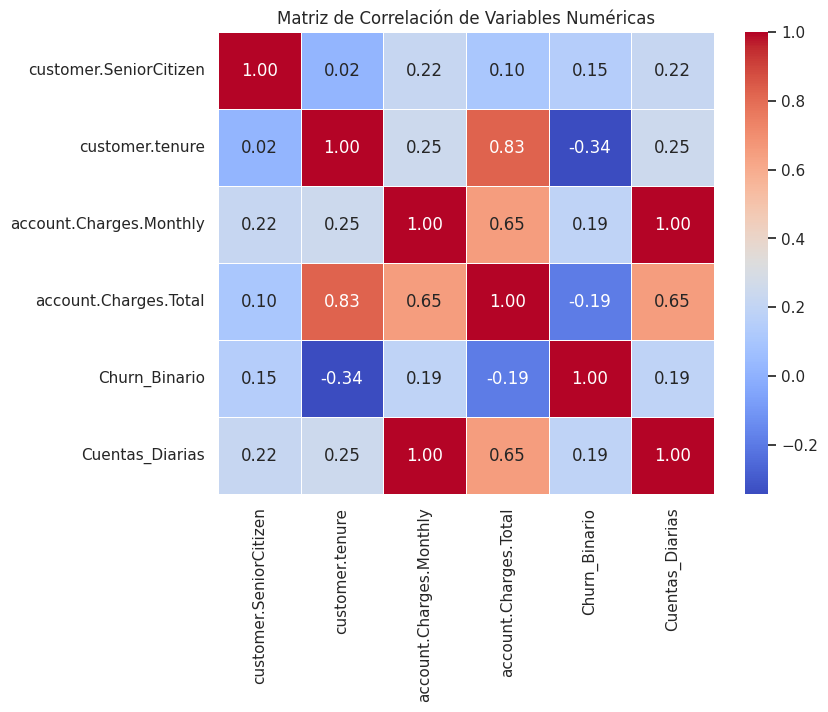

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Buscamos automáticamente los nombres exactos de las columnas en tu DataFrame actual
col_contrato = [col for col in df.columns if 'Contract' in col or 'contract' in col][0]
col_churn = [col for col in df.columns if 'Churn' in col or 'churn' in col and 'Binario' not in col][0]

# Configurar el estilo de los gráficos
sns.set_theme(style="whitegrid")

# Gráfico 1: Proporción total de clientes perdidos (Churn)
plt.figure(figsize=(6, 6))
conteo_churn = df[col_churn].value_counts()
plt.pie(conteo_churn, labels=conteo_churn.index, autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff9999'])
plt.title('Proporción de Evasión de Clientes (Churn)')
plt.show()

# Gráfico 2: Evasión según el Tipo de Contrato
plt.figure(figsize=(10, 5))
# Aquí usamos la variable detectada automáticamente (col_contrato) y la que creamos (Churn_Binario)
sns.countplot(data=df, x=col_contrato, hue='Churn_Binario', palette='Set2')
plt.title('Evasión de Clientes según el Tipo de Contrato (1 = Evasión, 0 = Retención)')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Cantidad de Clientes')
plt.show()

# Gráfico 3: Matriz de Correlación
plt.figure(figsize=(8, 6))
# Seleccionamos solo las variables numéricas para la matriz
cols_numericas = df.select_dtypes(include=[np.number])
sns.heatmap(cols_numericas.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

# 📄 Informe Final: Análisis de Evasión de Clientes (Churn) - Telecom X
**Autor:** [Escribe tu nombre aquí]

### 🔹 Introducción
Telecom X enfrenta un problema crítico de evasión de clientes (Churn). Este análisis tiene como objetivo identificar los principales factores y perfiles de riesgo que impulsan estas cancelaciones mediante técnicas de manipulación de datos (Pandas) y visualización (Seaborn y Matplotlib), preparando el terreno para el equipo de Data Science.

### 🔹 Limpieza y Tratamiento de Datos
* **Extracción:** Se obtuvieron los registros a través de la API en formato JSON.
* **Transformación:** Se corrigieron formatos de datos (ej. `TotalCharges` transformado a variable numérica continua y rellenando nulos).
* **Ingeniería de datos:** Se creó la métrica `Cuentas_Diarias` a partir del cargo mensual y se estandarizó la variable objetivo (`Churn`) a binaria (0 y 1).

### 🔹 Conclusiones e Insights
1. **El Tipo de Contrato es crítico:** El análisis exploratorio revela que la abrumadora mayoría de los clientes que cancelan el servicio poseen contratos "Month-to-month" (mes a mes). Los contratos anuales y bianuales presentan tasas de retención muy sólidas.
2. **Correlación Financiera:** Existe una correlación positiva visible entre el incremento de los cargos mensuales y la probabilidad de evasión.

### 🔹 Recomendaciones Estratégicas
1. **Campaña de Migración de Contratos:** Diseñar incentivos (descuentos o mejoras de velocidad) para que los clientes con formato "mes a mes" transicionen hacia contratos de 1 o 2 años.
2. **Retención Preventiva:** Detectar alertas de los clientes con los cargos mensuales más altos sin servicios de fidelización, y ofrecer paquetes de soporte técnico que reduzcan su probabilidad de abandono.